# Spatial Point Pattern Test (SPPT) - multiple crime themes within a district

This example compares the spatial distribution of crime across Bronx precincts between a test period and a preceding period of equal length.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

## Load the example data

The incident data contains crime records with an assigned precinct. The precinct GeoPackage will be used later to map the SPPT results.

In [2]:
# Paths relative to repo root
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

crime_file = ROOT / "crimepy" / "bronx_data.csv"
precinct_file = ROOT / "crimepy" / "bronx_precinct.gpkg" 

crime = pd.read_csv(crime_file)
precincts = gpd.read_file(precinct_file)

print(crime.columns.tolist())
print(precincts.columns.tolist())

['CMPLNT_NUM', 'CMPLNT_DATE_ISO', 'UBERHEX_FID', 'PRECINCT_ID', 'OFNS_DESC', 'X_COORD_CD', 'Y_COORD_CD', 'LATITUDE', 'LONGITUDE']
['id', 'precint', 'shape_length', 'shape_area', 'geometry']


## Run the SPPT

The test period is between `start_date` and `end_date` and is compared with `comparison`, which is a period of equal length either immediate before (`immediateprior`) or the same period as previous year (`sameperiodlastyear`).

In [3]:
from crimepy.sppt_scale import sppt_test

sppt_result = sppt_test(
    crime,
    start_date="2008-02-01",
    end_date="2008-11-30",
    theme_col="OFNS_DESC",
    unit_col="PRECINCT_ID",
    date_col="CMPLNT_DATE_ISO",
    x_col=None,
    y_col=None,
    comparison="sameperiodlastyear",
    date_format="%d/%m/%Y",
)

sppt_result.head()

,PRECINCT_ID,OFNS_DESC,n_base,n_test,N_base_total,N_test_total,p_base,p_test,diff,s_index,chi2_p,fdr_q,classification,direction,base_period_start,base_period_end,test_period_start,test_period_end,comparison_type
0,40.0,BURGLARY,204,238,3221.0,2879.0,0.063334,0.082668,0.019333,0.867582,4.260670e-03,0.079331,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
1,41.0,BURGLARY,167,158,3221.0,2879.0,0.051847,0.054880,0.003033,0.971583,6.387614e-01,1.000000,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
2,42.0,BURGLARY,271,146,3221.0,2879.0,0.084135,0.050712,-0.033423,0.752140,3.170219e-07,0.000012,Dissimilar (sig. change),Decrease,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
3,43.0,BURGLARY,343,315,3221.0,2879.0,0.106489,0.109413,0.002924,0.986455,7.442659e-01,1.000000,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
4,44.0,BURGLARY,281,235,3221.0,2879.0,0.087240,0.081626,-0.005614,0.966752,4.589488e-01,1.000000,Similar (no sig. change),Decrease,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear


## Review the SPPT results

The output reports change in each crime theme by precinct, including the S-index, significance test, FDR-adjusted value and direction of change.

In [4]:
# view single_theme results
view_single_theme = sppt_result[
sppt_result["OFNS_DESC"] == "BURGLARY"
]

view_single_theme.head(12)

,PRECINCT_ID,OFNS_DESC,n_base,n_test,N_base_total,N_test_total,p_base,p_test,diff,s_index,chi2_p,fdr_q,classification,direction,base_period_start,base_period_end,test_period_start,test_period_end,comparison_type
0,40.0,BURGLARY,204,238,3221.0,2879.0,0.063334,0.082668,0.019333,0.867582,4.260670e-03,0.079331,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
1,41.0,BURGLARY,167,158,3221.0,2879.0,0.051847,0.054880,0.003033,0.971583,6.387614e-01,1.000000,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
2,42.0,BURGLARY,271,146,3221.0,2879.0,0.084135,0.050712,-0.033423,0.752140,3.170219e-07,0.000012,Dissimilar (sig. change),Decrease,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
3,43.0,BURGLARY,343,315,3221.0,2879.0,0.106489,0.109413,0.002924,0.986455,7.442659e-01,1.000000,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
4,44.0,BURGLARY,281,235,3221.0,2879.0,0.087240,0.081626,-0.005614,0.966752,4.589488e-01,1.000000,Similar (no sig. change),Decrease,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
5,45.0,BURGLARY,216,231,3221.0,2879.0,0.067060,0.080236,0.013176,0.910546,5.457862e-02,0.677476,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
6,46.0,BURGLARY,241,212,3221.0,2879.0,0.074821,0.073637,-0.001185,0.992019,8.987218e-01,1.000000,Similar (no sig. change),Decrease,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
7,47.0,BURGLARY,317,293,3221.0,2879.0,0.098417,0.101771,0.003355,0.983242,6.941238e-01,1.000000,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
8,48.0,BURGLARY,265,242,3221.0,2879.0,0.082273,0.084057,0.001784,0.989272,8.371269e-01,1.000000,Similar (no sig. change),Increase,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear
9,49.0,BURGLARY,327,288,3221.0,2879.0,0.101521,0.100035,-0.001487,0.992625,8.808372e-01,1.000000,Similar (no sig. change),Decrease,2007-02-01,2007-11-30,2008-02-01,2008-11-30,sameperiodlastyear


## Map the SPPT results

The maps compare baseline crime counts, spatial similarity, and statistically significant changes. Significant changes are shown by direction.

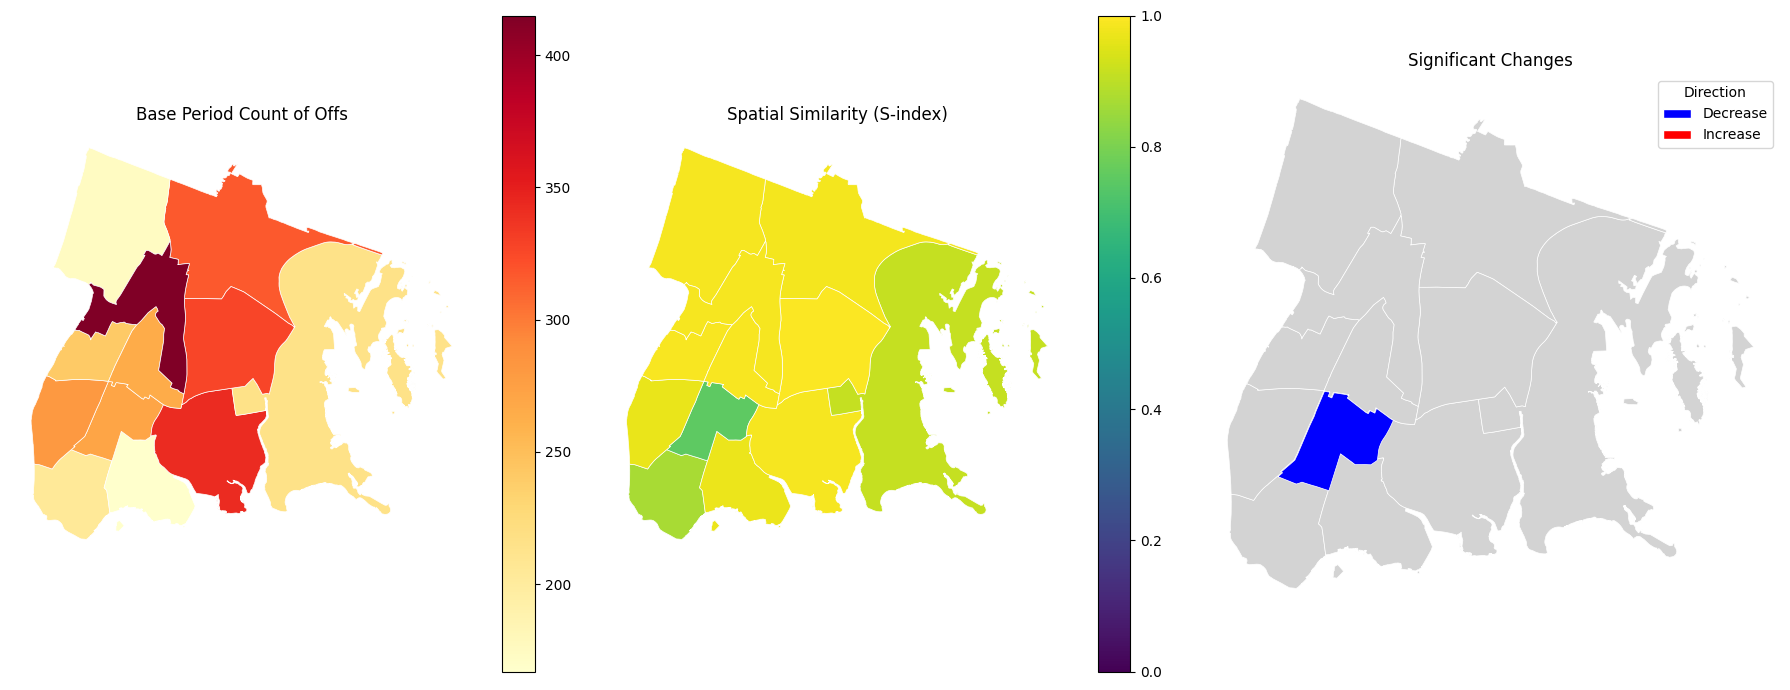

In [5]:
# Join results to precinct polygons
map_result = precincts.merge(
    view_single_theme,
    left_on="precint",
    right_on="PRECINCT_ID",
    how="left"
)

# Significant only
significant = map_result[
    map_result["classification"] == "Dissimilar (sig. change)"
].copy()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,7))

# base period
map_result.plot(
    column="n_base",
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    ax=axes[0]
)
axes[0].set_title("Base Period Count of Offs")
axes[0].set_axis_off()

# S-index
map_result.plot(
    column="s_index",
    cmap="viridis",
    vmin=0,
    vmax=1,
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    ax=axes[1]
)
axes[1].set_title("Spatial Similarity (S-index)")
axes[1].set_axis_off()

# Significant changes only
map_result.plot(
    color="lightgrey",
    edgecolor="white",
    linewidth=0.5,
    ax=axes[2]
)

decrease = significant[significant["direction"] == "Decrease"]

if not decrease.empty:
    decrease.plot(
        color="blue",
        edgecolor="white",
        linewidth=0.5,
        ax=axes[2],
        label='Decrease'
)

increase = significant[significant["direction"] == "Increase"]

if not increase.empty:
    increase.plot(
        color="red",
        edgecolor="white",
        linewidth=0.5,
        ax=axes[2],
        label='Increase'
)

axes[2].set_title("Significant Changes")
axes[2].set_axis_off()

legend_elements = [
    Patch(facecolor='blue', edgecolor='white', label='Decrease'),
    Patch(facecolor='red', edgecolor='white', label='Increase')
]

axes[2].legend(handles=legend_elements, title="Direction")

plt.tight_layout()
plt.show()